In [1]:
import os
import pandas as pd

# إنشاء مجلد باسم data
os.makedirs('data', exist_ok=True)

# رفع ملف البيانات من جهازك
from google.colab import files
uploaded = files.upload()

# نقل الملف إلى داخل مجلد data تلقائياً
for filename in uploaded.keys():
    os.rename(filename, os.path.join('data', filename))
    print(f"تم رفع الملف: {filename} ونقله إلى مجلد data بنجاح.")

Saving normalized_bankruptcy_dataset.csv to normalized_bankruptcy_dataset.csv
تم رفع الملف: normalized_bankruptcy_dataset.csv ونقله إلى مجلد data بنجاح.


In [2]:
import pandas as pd
import glob

# قراءة الملف من داخل مجلد data تلقائياً
file_path = glob.glob('data/*.csv')[0]
df = pd.read_csv(file_path)

print("أبعاد البيانات (الصفوف والأعمدة):", df.shape)
print("\nأسماء الأعمدة الموجودة في البيانات:")
print(df.columns.tolist())

print("\nعينة من أول صفين:")
display(df.head(2))

أبعاد البيانات (الصفوف والأعمدة): (49971, 10)

أسماء الأعمدة الموجودة في البيانات:
['Net Income to Total Assets', 'Debt Ratio', 'Working Capital to Total Assets', 'Current Ratio', 'Retained Earnings to Total Assets', 'ROA before interest and after tax', 'Total Asset Turnover', 'Net Worth to Assets', 'Gross Profit to Sales', 'Bankrupt']

عينة من أول صفين:


,Net Income to Total Assets,Debt Ratio,Working Capital to Total Assets,Current Ratio,Retained Earnings to Total Assets,ROA before interest and after tax,Total Asset Turnover,Net Worth to Assets,Gross Profit to Sales,Bankrupt
0,0.467153,0.472761,0.999320,1.474069e-10,0.484295,0.443902,0.000009,0.586394,0.125634,1
1,0.467635,0.472721,0.999483,1.487732e-10,0.484321,0.443999,0.000007,0.586438,0.125634,1


In [3]:
# تثبيت مكتبة LightGBM في حال لزم الأمر
!pip install -q lightgbm

import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

# 1. تحديد الميزات (Features) والمتغير المستهدف (Target)
X = df.drop(columns=['Bankrupt'])
y = df['Bankrupt']

# 2. إعداد استراتيجية التحقق الطبقي (Stratified K-Fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. إعداد معاملات نموذج LightGBM الأساسي
params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'random_state': 42,
    'n_jobs': -1
}

oof = np.zeros(len(X))

# التدريب والتققير عبر الطيات (Folds)
for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    oof[va_idx] = model.predict_proba(X_va)[:, 1]

# 4. طباعة مقاييس الأداء الأساسية (Baseline Evaluation)
print(f"Baseline ROC-AUC: {roc_auc_score(y, oof):.4f}")
print(f"Baseline PR-AUC: {average_precision_score(y, oof):.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1835, number of negative: 38141
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005694 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 39976, number of used features: 9
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.045903 -> initscore=-3.034245
[LightGBM] [Info] Start training from score -3.034245
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1835, number of negative: 38142
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[L

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# عمل مسح لقيم العتبات من 0.01 إلى 0.99
thresholds = np.linspace(0.01, 0.99, 99)
results = []

for t in thresholds:
    y_pred = (oof >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    results.append({'threshold': t, 'precision': precision, 'recall': recall, 'f1': f1})

res_df = pd.DataFrame(results)

# إيجاد العتبة التي تعطى أعلى F1-Score
best_row = res_df.loc[res_df['f1'].idxmax()]

print(f"أفضل عتبة قرار مقترحة (Best Threshold): {best_row['threshold']:.2f}")
print(f"مقابل F1-Score: {best_row['f1']:.4f}")
print(f"Precision: {best_row['precision']:.4f}")
print(f"Recall: {best_row['recall']:.4f}")

أفضل عتبة قرار مقترحة (Best Threshold): 0.14
مقابل F1-Score: 0.2695
Precision: 0.2384
Recall: 0.3099


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2294, number of negative: 47677
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004816 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 49971, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.045907 -> initscore=-3.034152
[LightGBM] [Info] Start training from score -3.034152


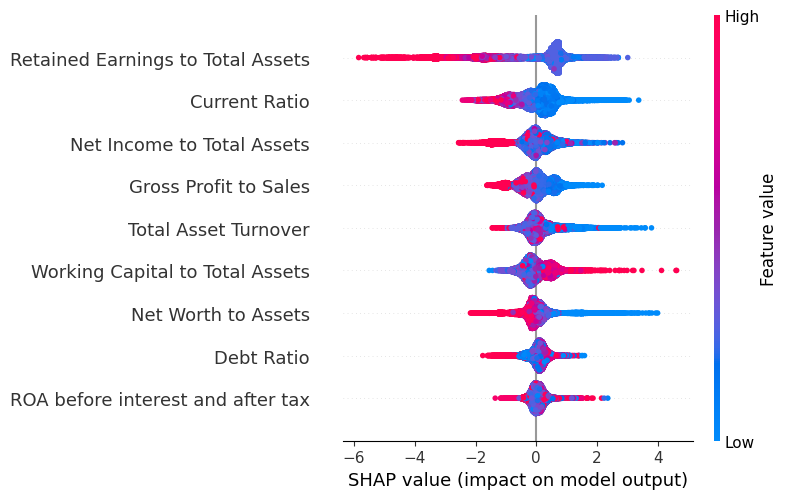

In [5]:
# تثبيت مكتبة SHAP
!pip install -q shap

import shap

# استخدام نموذج من الطيات أو تدريب نموذج نهائي على البيانات كاملة لاستخراج التفسيرات
import lightgbm as lgb
final_model = lgb.LGBMClassifier(**params)
final_model.fit(X, y)

# حساب قيم SHAP
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X)

# رسم ملخص تأثير الميزات (Summary Plot)
shap.summary_plot(shap_values, X)